# 문제 4 — 연립방정식과 해의 판정 (가우스 소거·rank·행렬식·역행렬)

풀어야 하는 연립방정식은 다음과 같습니다. 해는 정수로 떨어집니다.

$$\begin{aligned}
3x_1 + x_2 + 2x_3 &= 11\\
x_1 + 4x_2 + x_3 &= 1\\
2x_1 - x_2 + 5x_3 &= 20
\end{aligned}$$

## 이 노트북에서 해야 할 일

| # | 할 일 | 구현할 함수 |
|---|---|---|
| 4-1 | **가우스 소거법을 직접 구현**해 풀고 **각 소거 단계의 첨가행렬을 모두 출력** | `gauss_eliminate` |
| 4-2 | 계수행렬과 첨가행렬의 rank 로 **해의 존재·유일성 판정**, 같을 때와 다를 때의 의미 설명 | `rank` |
| 4-3 | 행렬식과 역행렬을 구하고, **det 이 0 에 가까울 때 왜 위험한지** 설명 | `det`, `inverse_gauss_jordan` |
| 4-4 | **피벗팅 없는** 소거로 첫 피벗이 아주 작을 때의 오차를 재현하고 부분 피벗팅과 비교 | `gauss_eliminate(pivoting=False)` |
| 4-5 | 800x800 에서 `np.linalg.solve` vs `역행렬을 구해서 곱하기` 의 **시간·잔차** 비교 | — |

> `# --- 검증 ---` 셀과 그래프 셀은 제공된 코드입니다. 참조하는 변수 이름을 맞춰 주세요.

In [1]:
import os

# 벤치마크 공정성을 위해 numpy import 전에 BLAS 스레드 수를 1 로 고정한다.
# 수백 x 수백 크기에서는 실제 연산보다 스레드 풀 생성/동기화 오버헤드가 더 커서
# 알고리즘 차이가 통째로 가려질 수 있다.
for _var in ("OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS", "OMP_NUM_THREADS", "NUMEXPR_NUM_THREADS"):
    os.environ[_var] = "1"

import inspect
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.vectors import det, gauss_eliminate, inverse_gauss_jordan, rank, row_echelon

rng = np.random.default_rng(42)
np.set_printoptions(precision=6, suppress=True)

for _f in ["Malgun Gothic", "AppleGothic", "NanumGothic", "DejaVu Sans"]:
    if _f in {f.name for f in __import__("matplotlib").font_manager.fontManager.ttflist}:
        plt.rcParams["font.family"] = _f
        break
plt.rcParams["axes.unicode_minus"] = False


def check(label, condition):
    tag = "PASS" if condition else "FAIL"
    print("[" + tag + "] " + label)
    return bool(condition)


# 풀어야 하는 연립방정식
A = np.array([[3.0, 1.0, 2.0],
              [1.0, 4.0, 1.0],
              [2.0, -1.0, 5.0]])
b = np.array([11.0, 1.0, 20.0])
print("A =\n", A, "\n\nb =", b)

A =
 [[ 3.  1.  2.]
 [ 1.  4.  1.]
 [ 2. -1.  5.]] 

b = [11.  1. 20.]


## 4-1. 가우스 소거법 — 단계별 첨가행렬

가우스 소거는 **첨가행렬 $[A|b]$ 에 행 연산만 적용**해 상삼각으로 만든 뒤
뒤에서부터 대입해 푸는 방법입니다. 행 연산은 해집합을 바꾸지 않습니다.

부분 피벗팅(partial pivoting)은 각 열에서 **절댓값이 가장 큰 성분을 피벗으로**
올리는 행 교환입니다. 왜 그렇게 하는지는 4-4 에서 직접 확인합니다.

**할 일**

- `src/vectors.py` 의 `gauss_eliminate` 를 구현하세요.
  `verbose=True` 면 **초기 첨가행렬과 각 단계(행 교환 / 소거)의 첨가행렬을 모두 출력**해야 합니다.
  반환값 `steps` 에는 단계별 첨가행렬(초기 포함)을 순서대로 담습니다.
- 구현한 소스를 `inspect.getsource` 로 노트북에 출력해 두세요.
- 해를 구하고 `A @ x` 가 `b` 와 같은지, 정수로 떨어지는지 확인하세요.
  **코드를 돌리기 전에 손으로 먼저 풀어 보고** 정수해를 예상해 두세요.

In [2]:
print(inspect.getsource(gauss_eliminate))

def gauss_eliminate(A, b, pivoting: bool = True, verbose: bool = False):
    """가우스 소거법 + 후진대입으로 Ax = b 를 푼다.

    Parameters
    ----------
    pivoting : True 면 부분 피벗팅을 적용한다. False 면 피벗을 그대로 쓴다
               (문제 4-4 에서 두 경우의 오차를 비교하므로 **둘 다 동작해야 한다**).
    verbose  : True 면 각 소거 단계의 첨가행렬 [A|b] 를 출력한다
               (문제 4-1 이 요구하는 '단계별 출력').

    Returns
    -------
    x : 해 벡터
    steps : 단계별 첨가행렬 [A|b] 스냅샷 리스트 (초기 상태 포함)

    피벗이 0 이면 해가 유일하지 않다 -> ZeroDivisionError.
    """
    # TODO: 문제 4-1
    A = np.array(A, dtype=float, copy=True)
    b = np.array(b, dtype=float, copy=True)

    if A.ndim !=2 or A.shape[0] != A.shape[1]:
        raise ValueError("A는 정사각행렬이어야 합니다.")

    n = A.shape[0]

    if b.shape != (n,):
        raise ValueError("b는 A의 행 개수와 같은 길이의 벡터여야 합니다.")

    augmented = np.column_stack([A, b])
    steps = [augmented.copy()]

    if verbose:
        print("초기 첨가행렬:")
        print(augmented)
    
    for col in range (n):
        if pivoting:
            pivot_row

In [3]:
# TODO: x, steps = gauss_eliminate(A, b, pivoting=True, verbose=True)
x, steps = gauss_eliminate(A, b, pivoting=True, verbose=True)

초기 첨가행렬:
[[ 3.  1.  2. 11.]
 [ 1.  4.  1.  1.]
 [ 2. -1.  5. 20.]]
0번 피벗으로 1번 행 소거:
[[ 3.        1.        2.       11.      ]
 [ 0.        3.666667  0.333333 -2.666667]
 [ 2.       -1.        5.       20.      ]]
0번 피벗으로 2번 행 소거:
[[ 3.        1.        2.       11.      ]
 [ 0.        3.666667  0.333333 -2.666667]
 [ 0.       -1.666667  3.666667 12.666667]]
1번 피벗으로 2번 행 소거:
[[ 3.        1.        2.       11.      ]
 [ 0.        3.666667  0.333333 -2.666667]
 [ 0.        0.        3.818182 11.454545]]


In [4]:
# TODO: 최종 해 x, 정수해 여부, A @ x, 잔차 |A x - b| 를 출력하세요.
print("최종 해 x =", x)
print("정수해 여부 :", np.allclose(x, np.round(x)), "->", np.round(x).astype(int))
print("\nA @ x  =", A @ x)
print("b      =", b)
print("잔차 |A x - b| =", format(np.linalg.norm(A @ x - b), ".3e"))

# TODO: np.linalg.solve(A, b) (# 비교 대상) 와도 비교하세요.
print("\nnp.linalg.solve =", np.linalg.solve(A, b), "  # 비교 대상")

최종 해 x = [ 2. -1.  3.]
정수해 여부 : True -> [ 2 -1  3]

A @ x  = [11.  1. 20.]
b      = [11.  1. 20.]
잔차 |A x - b| = 3.580e-15

np.linalg.solve = [ 2. -1.  3.]   # 비교 대상


In [5]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
ok = check("해가 (2, -1, 3)", np.allclose(x, [2.0, -1.0, 3.0]))
ok &= check("해가 정수로 떨어진다", np.allclose(x, np.round(x)))
ok &= check("A @ x == b", np.allclose(A @ x, b))
ok &= check("np.linalg.solve 와 일치", np.allclose(x, np.linalg.solve(A, b)))      # 비교 대상
ok &= check("소거 단계가 모두 기록되었다 (단계 수 {} >= 3)".format(len(steps)), len(steps) >= 3)
ok &= check("첫 기록이 초기 첨가행렬 [A|b]", np.allclose(steps[0], np.hstack([A, b.reshape(-1, 1)])))
ok &= check("마지막 첨가행렬이 상삼각", np.allclose(np.tril(steps[-1][:, :3], -1), 0.0))
ok &= check("상삼각의 대각성분 곱 == ±det(A) (행 연산은 det 의 부호만 바꾼다)",
            np.isclose(abs(np.prod(np.diag(steps[-1][:, :3]))), abs(det(A))))
print("\n4-1 전체 통과:", ok)

[PASS] 해가 (2, -1, 3)
[PASS] 해가 정수로 떨어진다
[PASS] A @ x == b
[PASS] np.linalg.solve 와 일치
[PASS] 소거 단계가 모두 기록되었다 (단계 수 4 >= 3)
[PASS] 첫 기록이 초기 첨가행렬 [A|b]
[PASS] 마지막 첨가행렬이 상삼각
[PASS] 상삼각의 대각성분 곱 == ±det(A) (행 연산은 det 의 부호만 바꾼다)

4-1 전체 통과: True


## 4-2. rank 로 해의 존재·유일성 판정

미지수가 $n$ 개일 때, **루셰-카펠리 정리**로 다음처럼 판정합니다.

| 조건 | 판정 |
|---|---|
| $\mathrm{rank}(A) = \mathrm{rank}([A\,|\,b]) = n$ | 유일해 |
| $\mathrm{rank}(A) = \mathrm{rank}([A\,|\,b]) < n$ | 해가 무한히 많음 (자유변수 $n - \mathrm{rank}$ 개) |
| $\mathrm{rank}(A) < \mathrm{rank}([A\,|\,b])$ | 해 없음 |

**할 일**

- 이 문제의 두 rank 를 `rA`, `rAb` 에 구해 판정하세요.
- 두 rank 가 같다는 것이 $b$ 와 $A$ 의 열공간 사이에서 무엇을 뜻하는지,
  다르면 소거 결과에 어떤 행이 나타나는지 **직접 예를 만들어** 확인하세요.
  아래 `A_dep` (2행이 1행의 배수) 에 모순되는 `b_bad` 와 모순 없는 `b_ok` 를 각각 넣어 봅니다.

### 두 rank 가 같을 때와 다를 때의 의미

- 같을 때: `_b가 A의 열공간 안에 있다는 뜻, Ax = b를 만족하는 x 존재_`
- 다를 때: `_소거 후 0 =(0이 아닌 수) 같은 모순 행이 생겼다는 의미._`
- 같지만 n 보다 작을 때: `_해가 무한히 많음 (자유변수 n - rank 개_`

In [6]:
Ab = np.hstack([A, b.reshape(-1, 1)])

A_dep = np.array([[1.0, 2.0, 3.0],
                  [3.0, 6.0, 9.0],      # 1행의 3배
                  [1.0, 1.0, 1.0]])

# TODO: rA = rank(A), rAb = rank(Ab), n_unknowns = A.shape[1] 을 출력하고 판정 결과를 출력하세요.

rA, rAb, n_unknowns = rank(A), rank(Ab), A.shape[1]
print("rank(A)      =", rA)
print("rank([A|b])  =", rAb)
print("미지수 개수 n =", n_unknowns)
print("\n판정 :", "유일해" if rA == rAb == n_unknowns else ("해 없음" if rA < rAb else "해 무한"))
print("np.linalg.matrix_rank :", np.linalg.matrix_rank(A), np.linalg.matrix_rank(Ab), "  # 검산용")

#       np.linalg.matrix_rank (# 검산용) 와도 비교하세요.
print("np.linalg.matrix_rank :", np.linalg.matrix_rank(A), np.linalg.matrix_rank(Ab), " # 검산용")


# TODO: b_bad (2행이 1행의 3배가 아니라 모순) 와 b_ok (모순 없음, 해 무한) 를 직접 만들어
b_bad = np.array([1.0, 2.0, 1.0])       # 2행은 2 여야 하는데 3 -> 모순
b_ok = np.array([1.0, 3.0, 1.0])        # 모순 없음 -> 해 무한
for name, bb in [("모순 (해 없음)", b_bad), ("무모순 (해 무한)", b_ok)]:
    ra = rank(A_dep)
    rab = rank(np.hstack([A_dep, bb.reshape(-1, 1)]))
    verdict = "유일해" if ra == rab == 3 else ("해 없음" if ra < rab else "해 무한 (자유변수 {}개)".format(3 - ra))
    print("\n[{}] rank(A)={}, rank([A|b])={} -> {}".format(name, ra, rab, verdict))

#       각각 판정과 소거 결과(row_echelon)의 마지막 행을 출력하세요.
    print("  소거 결과 마지막 행 :", row_echelon(np.hstack([A_dep, bb.reshape(-1, 1)]))[0][-1])

rank(A)      = 3
rank([A|b])  = 3
미지수 개수 n = 3

판정 : 유일해
np.linalg.matrix_rank : 3 3   # 검산용
np.linalg.matrix_rank : 3 3  # 검산용

[모순 (해 없음)] rank(A)=2, rank([A|b])=3 -> 해 없음
  소거 결과 마지막 행 : [0.       0.       0.       0.333333]

[무모순 (해 무한)] rank(A)=2, rank([A|b])=2 -> 해 무한 (자유변수 1개)
  소거 결과 마지막 행 : [0. 0. 0. 0.]


In [7]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
ok = check("rank(A) == 3 (full rank)", rA == 3)
ok &= check("rank([A|b]) == 3", rAb == 3)
ok &= check("두 rank 가 같고 n 과 같다 -> 유일해", rA == rAb == n_unknowns)
ok &= check("직접 구현 rank == np.linalg.matrix_rank",                                   # 검산용
            rA == np.linalg.matrix_rank(A) and rAb == np.linalg.matrix_rank(Ab))
ok &= check("A_dep 의 rank 는 2", rank(A_dep) == 2)
ok &= check("모순 케이스는 rank(A) < rank([A|b])",
            rank(A_dep) < rank(np.hstack([A_dep, np.asarray(b_bad, float).reshape(-1, 1)])))
ok &= check("무모순 종속 케이스는 두 rank 가 같고 n 보다 작다",
            rank(A_dep) == rank(np.hstack([A_dep, np.asarray(b_ok, float).reshape(-1, 1)])) < 3)
print("\n4-2 전체 통과:", ok)

[PASS] rank(A) == 3 (full rank)
[PASS] rank([A|b]) == 3
[PASS] 두 rank 가 같고 n 과 같다 -> 유일해
[PASS] 직접 구현 rank == np.linalg.matrix_rank
[PASS] A_dep 의 rank 는 2
[PASS] 모순 케이스는 rank(A) < rank([A|b])
[PASS] 무모순 종속 케이스는 두 rank 가 같고 n 보다 작다

4-2 전체 통과: True


## 4-3. 행렬식과 역행렬 — 그리고 $\det \approx 0$ 의 위험

행렬식은 행 사다리꼴의 **대각성분 곱 x (-1)^(행 교환 횟수)** 로 구합니다.
역행렬은 가우스-조던 소거 $[A|I] \rightarrow [I|A^{-1}]$ 로 구합니다.

**왜 $\det \approx 0$ 일 때 역행렬이 위험한지** 두 관점에서 설명해 보세요.

- 여인수 공식 $A^{-1} = \frac{1}{\det A}\mathrm{adj}(A)$ 에서 무슨 일이 생기는가
- 소거 관점에서 작은 피벗으로 나눈다는 것은 무엇을 뜻하는가

그리고 한 가지 더 확인해 보세요. $\det(cA)=c^n\det(A)$ 이므로
행렬 전체에 0.01 을 곱하기만 해도 $\det$ 는 크게 작아집니다.
그때 **해의 정확도도 같이 나빠지는지** 실험으로 확인하고,
그렇지 않다면 실무에서는 무엇을 기준으로 삼아야 하는지 조사해 적으세요.
(힌트: `np.linalg.cond`)

### det ≈ 0 이 위험한 이유와 진짜 판정 기준

- 여인수 공식 관점: `_여인수 공식에서 det가 작아질수록 성분이 폭발한다_`
- 소거 관점: `_아주 작은 피벗으로 나누는 것과 같이 반올림 오차가ㅏ 1/det 배로 증복됨._`
- 스케일 실험에서 관찰한 것: `_행렬식은 크게 작아졌지만 조건수는 같음_`
- 실무 판정 기준과 그 의미: `_행렬식의 절댓값만 보지 않고 조건수를 확인한다. 조건수가 커질수록 작은 입력 오차가 해의 큰 변화로 이어질 수 있어서 입력 오차와 필요한 정확도를 함께 고려해야 한다_`

In [8]:
# TODO: detA = det(A), invA = inverse_gauss_jordan(A) 를 구해 출력하고,
#       np.linalg.det / np.linalg.inv (# 검산용) 와 비교하세요.
detA = det(A)
invA = inverse_gauss_jordan(A)
print("det(A) (직접 구현) =", detA)
print("np.linalg.det(A)   =", np.linalg.det(A), "  # 검산용")
print("\nA^-1 (가우스-조던 직접 구현) =\n", invA)
print("\nnp.linalg.inv(A) =\n", np.linalg.inv(A), "  # 검산용")

# TODO: A @ invA == I 인지, invA @ b 가 4-1 의 해와 같은지 확인하세요.
print("\nA @ A^-1 =\n", A @ invA)
print("\nA^-1 @ b =", invA @ b, " (가우스 소거 해와 같아야 함)")

det(A) (직접 구현) = 42.0
np.linalg.det(A)   = 42.00000000000001   # 검산용

A^-1 (가우스-조던 직접 구현) =
 [[ 0.5      -0.166667 -0.166667]
 [-0.071429  0.261905 -0.02381 ]
 [-0.214286  0.119048  0.261905]]

np.linalg.inv(A) =
 [[ 0.5      -0.166667 -0.166667]
 [-0.071429  0.261905 -0.02381 ]
 [-0.214286  0.119048  0.261905]]   # 검산용

A @ A^-1 =
 [[ 1.  0.  0.]
 [ 0.  1. -0.]
 [ 0. -0.  1.]]

A^-1 @ b = [ 2. -1.  3.]  (가우스 소거 해와 같아야 함)


In [9]:
# TODO: (1) A 에 스케일 s = 1, 1e-1, 1e-2, 1e-3 을 곱해 가며
#           det / 조건수(np.linalg.cond) / 해의 상대오차를 표로 출력하세요.
# TODO: (2) 진짜 특이행렬에 가까워지는 예 (예: [[1,2],[2,4+eps]], b=[3, 6+eps], 참해 (1,1)) 로
#           eps 를 줄여 가며 같은 표를 출력하고, (1) 과 무엇이 다른지 보세요.

print("{:<14}{:>14}{:>16}{:>16}".format("s (스케일)", "det", "조건수", "해 상대오차"))
print("-" * 62)
scale_rows, dets, conds, errs = [], [], [], []
for s in [1.0, 1e-1, 1e-2, 1e-3]:
    As = A * s                       
    xs = np.linalg.solve(As, b * s)
    err = np.linalg.norm(xs - x) / np.linalg.norm(x)
    print("{:<14}{:>14.3e}{:>16.3e}{:>16.3e}".format(s, det(As), np.linalg.cond(As), err))

print("\n-> det 는 10^-9 배까지 작아졌지만 조건수와 오차는 그대로. det 크기는 판정 기준이 아니다.\n")

print("{:<16}{:>14}{:>16}{:>16}".format("eps (진짜 특이에 접근)", "det", "조건수", "해 상대오차"))
print("-" * 64)
for eps in [1e-2, 1e-6, 1e-10, 1e-14]:
    An = np.array([[1.0, 2.0], [2.0, 4.0 + eps]])     # eps -> 0 특이행렬
    bn = np.array([3.0, 6.0 + eps])                   # 참해는 (1, 1)
    xn = np.linalg.solve(An, bn)
    err = np.linalg.norm(xn - np.array([1.0, 1.0]))
    print("{:<16}{:>14.3e}{:>16.3e}{:>16.3e}".format(eps, det(An), np.linalg.cond(An), err))
print("\n-> 이쪽은 조건수가 같이 커지고 해도 실제로 무너진다. 위험한 것은 '작은 det' 가 아니라 '큰 조건수'.")

s (스케일)                  det             조건수          해 상대오차
--------------------------------------------------------------
1.0                4.200e+01       4.215e+00       1.454e-16
0.1                4.200e-02       4.215e+00       2.518e-16
0.01               4.200e-05       4.215e+00       3.026e-16
0.001              4.200e-08       4.215e+00       1.484e-16

-> det 는 10^-9 배까지 작아졌지만 조건수와 오차는 그대로. det 크기는 판정 기준이 아니다.

eps (진짜 특이에 접근)            det             조건수          해 상대오차
----------------------------------------------------------------
0.01                 1.000e-02       2.508e+03       0.000e+00
1e-06                1.000e-06       2.500e+07       0.000e+00
1e-10                1.000e-10       2.500e+11       0.000e+00
1e-14                9.770e-15       2.098e+15       0.000e+00

-> 이쪽은 조건수가 같이 커지고 해도 실제로 무너진다. 위험한 것은 '작은 det' 가 아니라 '큰 조건수'.


In [10]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
ok = check("det(A) == 42", np.isclose(detA, 42.0))
ok &= check("직접 구현 det == np.linalg.det", np.isclose(detA, np.linalg.det(A)))            # 검산용
ok &= check("A @ A^-1 == I", np.allclose(A @ invA, np.eye(3)))
ok &= check("A^-1 @ A == I", np.allclose(invA @ A, np.eye(3)))
ok &= check("직접 구현 역행렬 == np.linalg.inv", np.allclose(invA, np.linalg.inv(A)))       # 검산용
ok &= check("A^-1 @ b == 가우스 소거 해", np.allclose(invA @ b, x))
ok &= check("det(A^-1) == 1/det(A)", np.isclose(det(invA), 1.0 / detA))
ok &= check("det(0.01 A) == 0.01^3 det(A) (det 은 스케일에 민감)",
            np.isclose(det(0.01 * A), 1e-6 * detA))
ok &= check("조건수는 스케일에 무관", np.isclose(np.linalg.cond(0.01 * A), np.linalg.cond(A)))
print("\n4-3 전체 통과:", ok)

[PASS] det(A) == 42
[PASS] 직접 구현 det == np.linalg.det
[PASS] A @ A^-1 == I
[PASS] A^-1 @ A == I
[PASS] 직접 구현 역행렬 == np.linalg.inv
[PASS] A^-1 @ b == 가우스 소거 해
[PASS] det(A^-1) == 1/det(A)
[PASS] det(0.01 A) == 0.01^3 det(A) (det 은 스케일에 민감)
[PASS] 조건수는 스케일에 무관

4-3 전체 통과: True


## 4-4. 피벗팅 없는 소거의 오차

첫 피벗이 아주 작은 고전적인 예제입니다.

$$\begin{bmatrix}\varepsilon & 1\\ 1 & 1\end{bmatrix}
\begin{bmatrix}x_1\\x_2\end{bmatrix}=\begin{bmatrix}1\\2\end{bmatrix},
\qquad \text{참해}\;\; x_1=\frac{1}{1-\varepsilon},\; x_2=\frac{1-2\varepsilon}{1-\varepsilon}$$

**할 일**

- `pivoting=False` 와 `True` 로 각각 풀어 참해와의 상대오차를 비교하세요 ($\varepsilon=10^{-5}$).
- $\varepsilon$ 을 $10^{-2}$ 에서 $10^{-16}$ 까지 줄여 가며 두 오차를 표로 출력하고,
  아래 로그-로그 그래프(제공)로 확인하세요.
- 피벗팅이 없을 때 **정확히 어느 연산에서 유효숫자가 날아가는지** 설명하세요.

### 피벗팅 없이 소거하면 무슨 일이 일어나는가

- `_원래 O(1)이었던 숫자가 O(1/ε)의 스케일로 영향을 받아 유효 숫자가 날아간다_`

In [11]:
def solve_eps(eps):
    """eps 하나에 대해 (참해, 피벗팅 없음 해, 부분 피벗팅 해, 각각의 상대오차) 를 돌려준다."""
    # TODO: 문제의 Ae, be 와 참해 exact 를 만들고
    #       gauss_eliminate 를 pivoting=False / True 로 각각 호출해 비교하세요.
    #       return exact, x_no, x_pp, rel_err_no, rel_err_pp
    Ae = np.array([[eps, 1.0], [1.0, 1.0]])
    be = np.array([1.0, 2.0])
    exact = np.array([1.0 / (1.0 - eps), (1.0 - 2.0 * eps) / (1.0 - eps)])
    x_no, _ = gauss_eliminate(Ae, be, pivoting=False)
    x_pp, _ = gauss_eliminate(Ae, be, pivoting=True)
    rel = lambda v: np.linalg.norm(v - exact) / np.linalg.norm(exact)
    return exact, x_no, x_pp, rel(x_no), rel(x_pp)
    
EPS = 1e-5
eps_list = np.logspace(-2, -16, 15)

# TODO: exact, x_no, x_pp, err_no, err_pp = solve_eps(EPS) 를 출력하세요.
exact, x_no, x_pp, err_no, err_pp = solve_eps(EPS)
print("eps = {}".format(EPS))
print("  참해                :", exact)
print("  피벗팅 없음          :", x_no, "  상대오차 {:.3e}".format(err_no))
print("  부분 피벗팅          :", x_pp, "  상대오차 {:.3e}".format(err_pp))
print("  오차 비율 (없음/있음) : {:.3e} 배".format(err_no / max(err_pp, 1e-300)))

print("\neps 를 줄여 가며 비교")
print("{:<10}{:>18}{:>18}".format("eps", "피벗팅 없음 오차", "부분 피벗팅 오차"))
print("-" * 46)
# TODO: eps_list 를 돌며 errs_no, errs_pp 리스트를 채우고 표로 출력하세요.
#       (로그 그래프를 위해 0 은 max(err, 1e-18) 로 바닥을 깔아 두세요)
errs_no, errs_pp = [], []
for e in eps_list:
    _, _, _, en, ep = solve_eps(e)
    errs_no.append(max(en, 1e-18))
    errs_pp.append(max(ep, 1e-18))
    print("{:<10.0e}{:>18.3e}{:>18.3e}".format(e, en, ep))

eps = 1e-05
  참해                : [1.00001 0.99999]
  피벗팅 없음          : [1.00001 0.99999]   상대오차 2.690e-12
  부분 피벗팅          : [1.00001 0.99999]   상대오차 0.000e+00
  오차 비율 (없음/있음) : 2.690e+288 배

eps 를 줄여 가며 비교
eps                피벗팅 없음 오차         부분 피벗팅 오차
----------------------------------------------
1e-02              3.297e-15         1.570e-16
1e-03              1.601e-14         0.000e+00
1e-04              1.989e-13         1.570e-16
1e-05              2.690e-12         0.000e+00
1e-06              3.984e-12         1.570e-16
1e-07              3.563e-10         0.000e+00
1e-08              3.518e-09         1.570e-16
1e-09              2.071e-08         0.000e+00
1e-10              5.844e-08         0.000e+00
1e-11              5.850e-08         0.000e+00
1e-12              1.564e-05         0.000e+00
1e-13              2.199e-04         1.570e-16
1e-14              5.652e-04         0.000e+00
1e-15              5.652e-04         1.570e-16
1e-16              8.630e-01         1.

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

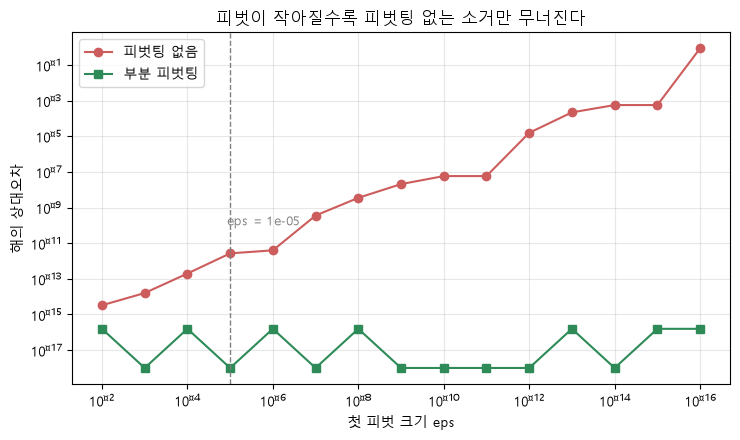

In [12]:
# --- 그래프 (제공 코드) ---
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.loglog(eps_list, errs_no, "o-", color="indianred", label="피벗팅 없음")
ax.loglog(eps_list, errs_pp, "s-", color="seagreen", label="부분 피벗팅")
ax.axvline(EPS, ls="--", color="gray", lw=1)
ax.text(EPS * 1.2, 1e-10, "eps = {:g}".format(EPS), color="gray", fontsize=9)
ax.invert_xaxis()
ax.set_xlabel("첫 피벗 크기 eps")
ax.set_ylabel("해의 상대오차")
ax.set_title("피벗이 작아질수록 피벗팅 없는 소거만 무너진다")
ax.grid(alpha=0.3, which="both")
ax.legend()
fig.tight_layout()
plt.show()

In [13]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
ok = check("eps=1e-5 에서 피벗팅 없는 쪽의 오차가 더 크다", err_no > err_pp)
ok &= check("부분 피벗팅 오차는 기계정밀도 수준 (< 1e-15)", err_pp < 1e-15)
ok &= check("eps 가 작아질수록 피벗팅 없는 오차가 커진다", errs_no[-1] > errs_no[0])
ok &= check("eps=1e-16 근처에서는 피벗팅 없는 해가 완전히 무너진다 (오차 > 0.1)", errs_no[-1] > 0.1)
ok &= check("부분 피벗팅은 eps 와 무관하게 안정적", max(errs_pp) < 1e-14)
ok &= check("피벗팅 결과는 np.linalg.solve 와 일치",                                          # 비교 대상
            np.allclose(x_pp, np.linalg.solve(np.array([[EPS, 1.0], [1.0, 1.0]]), [1.0, 2.0])))
print("\n4-4 전체 통과:", ok)

[PASS] eps=1e-5 에서 피벗팅 없는 쪽의 오차가 더 크다
[PASS] 부분 피벗팅 오차는 기계정밀도 수준 (< 1e-15)
[PASS] eps 가 작아질수록 피벗팅 없는 오차가 커진다
[PASS] eps=1e-16 근처에서는 피벗팅 없는 해가 완전히 무너진다 (오차 > 0.1)
[PASS] 부분 피벗팅은 eps 와 무관하게 안정적
[PASS] 피벗팅 결과는 np.linalg.solve 와 일치

4-4 전체 통과: True


## 4-5. 800x800 — `solve` vs `역행렬을 구해서 곱하기`

**할 일**

- 800x800 무작위 행렬에서 `np.linalg.solve(A, b)` 와 `np.linalg.inv(A) @ b` 의
  **실행 시간과 잔차**를 각각 측정해 표와 막대그래프(제공)로 비교하세요.
- 벤치마크는 **워밍업 1회 후 여러 번 재서 최솟값**을 씁니다. (`bench` 제공)
  평균 대신 최솟값을 쓰는 이유도 생각해 보세요.
- 조건수가 좋은 행렬에서는 잔차 차이가 잘 안 보입니다.
  조건수를 지정한 행렬을 만들어(예: SVD 형태로 조립) 조건수별 오차를 비교해 보세요.
- 두 방법의 **연산량**이 각각 얼마인지 조사해 표로 정리하고,
  실무에서 어느 쪽을 써야 하는지 근거와 함께 결론을 쓰세요.

### 결론 — 실무에서는 무엇을 쓰는가

- 연산량: `_solve가 더 빠르다_`
- 정확도: `_solve가 오차가 낮다_`
- 메모리: `_solve 는 b 하나(4 KB), inv 는 800 x 800 행렬(5.1 MB) 을 따로 저장_`
- 우변이 여러 개일 때는: `_역행렬을 A-1 미리 구해 두고, 벡터를 그 역행렬과 계속 솝하는 것이 효율적. solve로 매번 새로 시작하는 것보다 연산 횟수를 줄일 수 있기 때문_`
- 예외적으로 역행렬을 명시적으로 구해야 하는 경우: `_우번 벡터가 계속 바뀌면서 매우 많이 주어질 때 또는 반복적으로 여러 다른 우변에 대해 방정식을 풀어야 할 때._`

In [14]:
N = 800
A_big = rng.standard_normal((N, N))
b_big = rng.standard_normal(N)
REPEAT = 10


def bench(fn, repeat=REPEAT):
    """워밍업 1회 후 repeat 번 재서 최솟값을 쓴다. (그대로 쓰면 됩니다)"""
    fn()                                     # 워밍업 (LAPACK 초기화, 캐시 적재)
    best = float("inf")
    for _ in range(repeat):
        t0 = time.perf_counter()
        out = fn()
        best = min(best, time.perf_counter() - t0)
    return best, out


# TODO: 아래 변수를 만들어 표로 출력하세요.
t_solve, x_solve = bench(lambda: np.linalg.solve(A_big, b_big))
t_inv,   x_inv   = bench(lambda: np.linalg.inv(A_big) @ b_big)

res_solve = np.linalg.norm(A_big @ x_solve - b_big)
res_inv = np.linalg.norm(A_big @ x_inv - b_big)

print("행렬 크기 : {0}x{0},  조건수 {1:.3e}".format(N, np.linalg.cond(A_big)))
print("\n{:<26}{:>14}{:>16}".format("방법", "시간 [ms]", "잔차 |Ax-b|"))
print("-" * 56)
print("{:<26}{:>14.3f}{:>16.3e}".format("np.linalg.solve", t_solve * 1e3, res_solve))
print("{:<26}{:>14.3f}{:>16.3e}".format("np.linalg.inv(A) @ b", t_inv * 1e3, res_inv))
print("\n속도 비율 : inv 방식이 {:.2f} 배 느림".format(t_inv / t_solve))
print("잔차 비율 : inv / solve = {:.2f}".format(res_inv / res_solve))

#   메모리 사용량 차이(역행렬 N*N*8 바이트)도 함께 적으면 좋습니다.
print("메모리     : solve 는 b 하나(4 KB), inv 는 {} x {} 행렬({:.1f} MB) 을 따로 저장".format(
    N, N, N * N * 8 / 1e6))

행렬 크기 : 800x800,  조건수 2.533e+03

방법                               시간 [ms]       잔차 |Ax-b|
--------------------------------------------------------
np.linalg.solve                   13.391       9.038e-12
np.linalg.inv(A) @ b              45.061       1.702e-11

속도 비율 : inv 방식이 3.36 배 느림
잔차 비율 : inv / solve = 1.88
메모리     : solve 는 b 하나(4 KB), inv 는 800 x 800 행렬(5.1 MB) 을 따로 저장


In [15]:
# TODO: 조건수를 지정한 행렬을 만들어 조건수별 해의 상대오차를 비교 출력하세요.
#       (힌트: np.linalg.qr 로 만든 직교행렬 두 개 Q1, Q2 와 np.logspace 로 만든 특이값 sv 로
#              (Q1 * sv) @ Q2.T 를 조립하면 조건수가 sv.max()/sv.min() 인 행렬이 됩니다)
def make_conditioned(n, cond, gen):
    """지정한 조건수를 갖는 n x n 행렬을 SVD 형태로 조립한다."""
    Q1, _ = np.linalg.qr(gen.standard_normal((n, n)))
    Q2, _ = np.linalg.qr(gen.standard_normal((n, n)))
    sv = np.logspace(0, -np.log10(cond), n)
    return (Q1 * sv) @ Q2.T


print("\n\n조건수별 해의 상대오차 (200x200, 참해 = 전부 1)")
print("{:<14}{:>18}{:>18}".format("조건수", "solve 오차", "inv @ b 오차"))
print("-" * 50)
cond_list, err_solve_list, err_inv_list = [], [], []
x_true_big = np.ones(200)
for c in [1e2, 1e6, 1e10, 1e13]:
    Ac = make_conditioned(200, c, rng)
    bc = Ac @ x_true_big
    e_s = np.linalg.norm(np.linalg.solve(Ac, bc) - x_true_big) / np.linalg.norm(x_true_big)
    e_i = np.linalg.norm(np.linalg.inv(Ac) @ bc - x_true_big) / np.linalg.norm(x_true_big)
    cond_list.append(c)
    err_solve_list.append(e_s)
    err_inv_list.append(e_i)
    print("{:<14.0e}{:>18.3e}{:>18.3e}".format(c, e_s, e_i))
print("\n-> 조건수가 나빠질수록 inv 방식의 오차가 더 빨리 커진다.")
print("   역행렬을 n^2 개 성분으로 반올림해 저장했다가 다시 곱하는 만큼 반올림이 한 단계 더 들어가기 때문이다.")



조건수별 해의 상대오차 (200x200, 참해 = 전부 1)
조건수                     solve 오차        inv @ b 오차
--------------------------------------------------
1e+02                  1.148e-14         5.155e-14
1e+06                  1.796e-11         2.691e-10
1e+10                  1.022e-07         1.387e-06
1e+13                  1.351e-04         2.308e-03

-> 조건수가 나빠질수록 inv 방식의 오차가 더 빨리 커진다.
   역행렬을 n^2 개 성분으로 반올림해 저장했다가 다시 곱하는 만큼 반올림이 한 단계 더 들어가기 때문이다.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


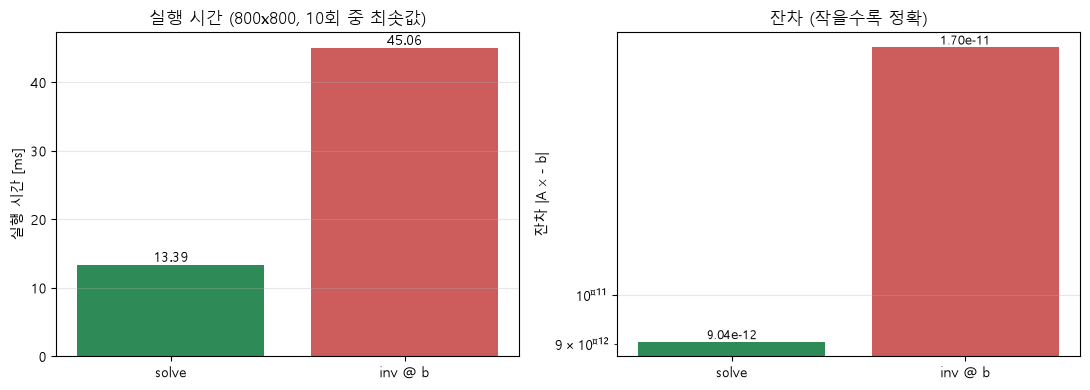

In [16]:
# --- 그래프 (제공 코드) ---
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
names = ["solve", "inv @ b"]

axes[0].bar(names, [t_solve * 1e3, t_inv * 1e3], color=["seagreen", "indianred"])
axes[0].set_ylabel("실행 시간 [ms]")
axes[0].set_title("실행 시간 ({0}x{0}, {1}회 중 최솟값)".format(N, REPEAT))
for i, v in enumerate([t_solve * 1e3, t_inv * 1e3]):
    axes[0].text(i, v, "{:.2f}".format(v), ha="center", va="bottom")
axes[0].grid(alpha=0.3, axis="y")

axes[1].bar(names, [res_solve, res_inv], color=["seagreen", "indianred"])
axes[1].set_ylabel("잔차 |A x - b|")
axes[1].set_yscale("log")
axes[1].set_title("잔차 (작을수록 정확)")
for i, v in enumerate([res_solve, res_inv]):
    axes[1].text(i, v, "{:.2e}".format(v), ha="center", va="bottom", fontsize=9)
axes[1].grid(alpha=0.3, axis="y")

fig.tight_layout()
plt.show()

In [17]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
ok = check("두 방법의 해가 사실상 같다", np.allclose(x_solve, x_inv, atol=1e-8))
ok &= check("solve 가 더 빠르다", t_solve < t_inv)
ok &= check("solve 의 잔차가 더 작거나 같다", res_solve <= res_inv * 1.5)
ok &= check("두 해 모두 유효 (잔차가 작다)", res_solve < 1e-8 and res_inv < 1e-8)
print("\n4-5 전체 통과:", ok)

[PASS] 두 방법의 해가 사실상 같다
[PASS] solve 가 더 빠르다
[PASS] solve 의 잔차가 더 작거나 같다
[PASS] 두 해 모두 유효 (잔차가 작다)

4-5 전체 통과: True


## 답안 템플릿 정리

In [18]:
summary = """
1. 가우스 소거 단계별 첨가행렬: 4-1 셀 출력 참조
   최종 해: x = [ 2. -1.  3.]

2. rank A: {ra} / rank 첨가행렬: {rab}   (미지수 3개)
   - 해의 존재·유일성 판정: rank(A) = rank([A|b]) = n = 3 이므로 해가 존재하고 유일하다.
   - 두 rank 가 같을 때 / 다를 때 / 같지만 n 보다 작을 때: 
       - 같을 때 = b 가 A 의 열공간 안에 있어 해가 존재하고
       - 다를 때 = 소거 후 '0 = 0이 아닌 수' 모순 행이 생겨 해가 없다.
       - 같지만 n 보다 작으면 자유변수가 생겨 해가 무한히 많다.
       

3. 행렬식: {dt:.1f}
   역행렬:
   {inv}
   - det 이 0 에 가까울 때 위험한 이유: A^-1 = adj(A)/det(A) 의 성분이 폭발하고,
                                        소거 관점에서는 아주 작은 피벗으로 나누는 셈이라 반올림 오차가 증폭된다.
                                        
   - 실제 판정 기준: det 크기 자체는 스케일에 따라 변하므로 실제 판정 기준은 조건수다.

4. 피벗팅 없을 때 오차 / 부분 피벗팅 오차 (eps = 1e-5): 
    {e_no:.3e} / {e_pp:.3e} -> {ratio:.2e} 배 차이
   - eps 를 더 줄이면: 무너진다
   - 유효숫자가 날아가는 지점: {worst:.2e}

5. solve vs 역행렬 곱셈 (800x800)
   - 시간 : {ts:.3f} ms / {ti:.3f} ms
   - 잔차 : {rs:.3e} / {ri:.3e}
   - 조건수를 키웠을 때의 정확도 차이:
       cond 1e10 : solve {es10:.3e} / inv {ei10:.3e}
       cond 1e13 : solve {es13:.3e} / inv {ei13:.3e}
   - 결론: solve 를 쓴다. 연산량이 (2/3)n^3 vs 약 2n^3 이라 {tr:.1f} 배 느리고,
     역행렬은 n^2 개 성분을 반올림해 저장했다 다시 곱하므로 조건수가 나쁠수록 오차가 커지며,
     메모리도 {mem:.1f} MB 를 더 쓴다. 우변이 여러 개면 inv 대신 LU 분해를 한 번 하고 재사용한다.
""".format(
    sol=np.round(x, 10),
    ra=rA, rab=rAb, dt=detA,
    inv="\n".join("     " + line for line in np.array2string(invA, precision=6).splitlines()),
    e_no=err_no, e_pp=err_pp, ratio=err_no / max(err_pp, 1e-300),
    worst=errs_no[-1],
    n=N, rep=REPEAT,
    ts=t_solve * 1e3, ti=t_inv * 1e3, tr=t_inv / t_solve,
    rs=res_solve, ri=res_inv, cnd=np.linalg.cond(A_big),
    es10=err_solve_list[2], ei10=err_inv_list[2],
    es13=err_solve_list[3], ei13=err_inv_list[3],
    mem=N * N * 8 / 1e6,
)
print(summary)


1. 가우스 소거 단계별 첨가행렬: 4-1 셀 출력 참조
   최종 해: x = [ 2. -1.  3.]

2. rank A: 3 / rank 첨가행렬: 3   (미지수 3개)
   - 해의 존재·유일성 판정: rank(A) = rank([A|b]) = n = 3 이므로 해가 존재하고 유일하다.
   - 두 rank 가 같을 때 / 다를 때 / 같지만 n 보다 작을 때: 
       - 같을 때 = b 가 A 의 열공간 안에 있어 해가 존재하고
       - 다를 때 = 소거 후 '0 = 0이 아닌 수' 모순 행이 생겨 해가 없다.
       - 같지만 n 보다 작으면 자유변수가 생겨 해가 무한히 많다.


3. 행렬식: 42.0
   역행렬:
        [[ 0.5      -0.166667 -0.166667]
      [-0.071429  0.261905 -0.02381 ]
      [-0.214286  0.119048  0.261905]]
   - det 이 0 에 가까울 때 위험한 이유: A^-1 = adj(A)/det(A) 의 성분이 폭발하고,
                                        소거 관점에서는 아주 작은 피벗으로 나누는 셈이라 반올림 오차가 증폭된다.

   - 실제 판정 기준: det 크기 자체는 스케일에 따라 변하므로 실제 판정 기준은 조건수다.

4. 피벗팅 없을 때 오차 / 부분 피벗팅 오차 (eps = 1e-5): 
    2.690e-12 / 0.000e+00 -> 2.69e+288 배 차이
   - eps 를 더 줄이면: 무너진다
   - 유효숫자가 날아가는 지점: 8.63e-01

5. solve vs 역행렬 곱셈 (800x800)
   - 시간 : 13.391 ms / 45.061 ms
   - 잔차 : 9.038e-12 / 1.702e-11
   - 조건수를 키웠을 때의 정확도 차이:
       cond 1e10 : solve 1.022e-07 / inv 1.387e-06
    